### Importing necessary packages and files

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import paretoset
import periodictable
from pymatgen.core import Structure
import ast
from sklearn.linear_model import ElasticNet
from xgboost import XGBRegressor

In [2]:
pdata = pd.read_excel("MATSCI_176_Project_Data (1).xlsx")
pdata.head()

,battery_formula,working_ion,elements,nelements,formula_charge,formula_discharge,max_delta_volume,average_voltage,capacity_grav,capacity_vol,...,energy_vol,stability_charge,stability_discharge,electrode_density,material_density,battery_workingion_cost_per_kWh,structure,formation_energy_per_atom,band_gap,energy_density
0,Li0-3Ag,Li,['Ag'],1.0,Ag,Li3Ag,2.736089,0.210565,624.785871,1984.816229,...,417.933696,0.003609,0.000000,3.176794,2.592432,108.0,"{'@module': 'pymatgen.core.structure', '@class...",0.333634,0,417.933696
1,Li0-3Sb,Li,['Sb'],1.0,Sb,Li3Sb,1.569237,1.015953,563.913254,1890.293779,...,1920.448911,0.328351,0.000000,3.352100,3.378028,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.744135,0.7074,1920.448911
2,Li0-1Bi,Li,['Bi'],1.0,Bi,LiBi,0.368255,0.796796,124.126099,923.538664,...,735.871648,0.049545,0.000000,7.440326,2.237712,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.034716,0,735.871648
3,Li0-3Ce,Li,['Ce'],1.0,Ce,Li3Ce,2.951183,-0.444846,499.595769,1295.168213,...,-576.149771,0.000000,0.333634,2.592432,2.583328,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.330999,0,576.149771
4,Li0-3Ca,Li,['Ca'],1.0,Ca,Li3Ca,1.513956,-0.064931,1320.248328,1271.741142,...,-82.574983,0.000000,0.057445,0.963259,7.527518,108.0,"{'@module': 'pymatgen.core.structure', '@class...",-0.415156,0,82.574983


In [3]:
structures = pdata["structure"]
print(structures.shape)
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)
print(structure_test)
print(structure_test.lattice.abc)
print(structure_test.volume)

(5786,)
Full Formula (Li3 Sb1)
Reduced Formula: Li3Sb
abc   :   4.627959   4.627959   4.627959
angles:  60.000007  60.000010  60.000007
pbc   :       True       True       True
Sites (4)
  #  SP       a      b     c    magmom
---  ----  ----  -----  ----  --------
  0  Li    0.5    0.5   0.5          0
  1  Li    0.25   0.25  0.25        -0
  2  Li    0.75   0.75  0.75        -0
  3  Sb    0     -0     0            0
(4.627959209506349, 4.627958733729667, 4.62795882)
70.08959778250679


In [4]:
def get_volume(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.volume
    except:
        return np.nan
# structure_volums = pdata["structure"].apply(get_volume) # Volumes in Angstrom^3
def get_abc(structure_str):
    try:
        structure_dict = ast.literal_eval(structure_str)
        structure = Structure.from_dict(structure_dict)
        return structure.lattice.abc
    except:
        return np.nan
structure_abc = pdata["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
pdata = pdata.drop(columns=["structure"], axis=1)
pdata = pd.concat([pdata, structure_abc_df], axis=1)

In [5]:
numeric_cols = [
    "material_density",
    "formation_energy_per_atom",
    "band_gap"
]

for col in numeric_cols:
    pdata[col] = pd.to_numeric(pdata[col], errors="coerce")
pdata = pdata.dropna()
pdata = pdata.reset_index(drop=True)
pdata_norm = pdata.iloc[:, 6:]

#### Defining our scoring function(s) to analyze and their input datasets.
We don't want to train our model on the features which are used for scoring. Therefore, we need to define a new training dataset excluding these features. Our scoring model uses gravimetric energy, gravimetric capacity, battery cost per liter, energy density, and battery voltage, so we removed these from our training data set. Additionally, features like energy volume, capacity volume, and electrode density are correlated with battery cost and energy density (as they're used in the calculations for those features), so we removed those columns from our training data to avoid any overlap.

In [6]:
# Getting the energy grav, capacity grav, battery cost per L, energy density, and average voltage columns for scoring and removing those and additional columns from the training data
energy_grav = pdata_norm["energy_grav"]
cap_grav = pdata_norm["capacity_grav"]
energy_density = pdata_norm["energy_density"]
voltage = pdata_norm['average_voltage']
training_data = pdata_norm.drop(columns=["energy_grav", "energy_density", "electrode_density", "stability_charge", "energy_vol", "capacity_vol"])
training_data["average_voltage"] = np.abs(training_data["average_voltage"])
training_data_nocost = training_data.drop(columns=["battery_workingion_cost_per_kWh"])


In [7]:
def scoring_nocost(e_g):
    e_g = e_g.to_numpy().astype(float)
    score = np.abs(e_g)
    return pd.Series(score)

### Benchmarking the Ridge & Elastic Net Regressional Models
We chose ridge regression and elasticnet regression to both identify important features (from the elastic component) while zeroing out features which don't affect battery performance (features that don't affect our score.)

In [8]:
# Testing the no-cst scoring function and defining our fit & training datasets.
# battery_score = scoring_nocost(cap_grav, energy_density, voltage)
battery_score = scoring_nocost(energy_grav)

fit_train, fit_test, score_train, score_test = train_test_split(
    training_data_nocost,
    battery_score,
    test_size=0.1,
    random_state=42
)

# Normalization of the fit and training datasets for better performance of the elastic net model, since it is sensitive to the scale of the features
norm_fit_train = pd.DataFrame(
    StandardScaler().fit_transform(fit_train),
    columns=fit_train.columns
)
norm_fit_test = pd.DataFrame(
    StandardScaler().fit_transform(fit_test),
    columns=fit_test.columns
)

In [9]:
ridge = linear_model.Ridge(alpha=3.0).fit(fit_train, score_train, sample_weight=None)
score_pred = ridge.score(fit_test, score_test)
print(f"Effective R^2 score: {score_pred:.3f}")

Effective R^2 score: 0.603


In [10]:
best = np.where(battery_score == np.max(battery_score))[0][0]
print(pdata.iloc[best])
print("Battery Score:", np.max(battery_score))


battery_formula                       Li0-3ClO
working_ion                                 Li
elements                           ['Cl', 'O']
nelements                                  2.0
formula_charge                             ClO
formula_discharge                       Li3ClO
max_delta_volume                      1.020934
average_voltage                       4.299346
capacity_grav                      1112.473171
capacity_vol                       2236.418805
energy_grav                        4782.906878
energy_vol                         9615.137841
stability_charge                      1.553271
stability_discharge                   0.027568
electrode_density                     2.010313
material_density                      3.455668
battery_workingion_cost_per_kWh          108.0
formation_energy_per_atom            -0.151988
band_gap                                   0.0
energy_density                     9615.137841
a                                     4.677535
b            



## Performing K-folds cross validation on our ridge regressional model.
Choosing k-folds is important to determine if our train-validation split was truely indicative of the full system.

In [11]:
X = training_data_nocost
y = battery_score
y = y.fillna(0)
y = y.astype(float)

In [12]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", linear_model.Ridge(alpha=3.0))
])

In [13]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_ridge = []
params = []
best_ridge_score = []

for train_idx, test_idx in kf.split(X):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    ridge_pipeline.fit(X_train, y_train)
    y_pred = ridge_pipeline.predict(X_test)
    params.append(ridge_pipeline.named_steps["ridge"].coef_)

    #Find best material in predicted set
    bestmaterial_ridge.append(X_test.iloc[np.where(y_pred == np.max(y_pred))[0][0]])
    best_ridge_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))
bestmaterial_df_ridge = pd.DataFrame(bestmaterial_ridge)

Mean R2: 0.5621540601761627
Mean MSE: 44804.44849372668
Mean MAE: 127.01733771171118


In [14]:
# Converting the best material features back to the original scale for comparison with the original dataset, since we normalized the training & test data.
# To do so, we took the best material from each fold and compared their features to the original datasets to find the approximated battery  (the battery formula with the smallest minimum difference between predicted best and the rest of the dataset).
for i in range(len(bestmaterial_df_ridge)):
    best_material = bestmaterial_df_ridge.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material - pdata.iloc[j, 6:6+len(best_material)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Li0-1Cr2(PO4)3
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Mg7-149Cr
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Mg7-149V


## Performing K-folds cross validation on our ElasticNet Model

In [15]:
alpha = 3.25
l1_ratio = 0.5 # 0=ridge-like, 1=lasso-like

enet_pipeline = Pipeline([
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

score_pred_enet = enet_pipeline.fit(fit_train, score_train).score(fit_test, score_test)
print("ElasticNet test R^2:", score_pred_enet)

ElasticNet test R^2: 0.5366851725714992


In [16]:
#replace Ridge KFold with Elastic Net KFold

X = training_data_nocost
y = battery_score.fillna(0).astype(float)

# Elastic Net hyperparameters
alpha = 3.25
l1_ratio = 0.5

enet_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=20000, random_state=42))
])

kf = KFold(n_splits=10, shuffle=True, random_state=42)

r2_scores = []
MAE = []
MSE = []
bestmaterial_elastic = []
best_elastic_score = []

for train_idx, test_idx in kf.split(X):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    enet_pipeline.fit(X_train, y_train)
    y_pred = enet_pipeline.predict(X_test)
    bestmaterial_elastic.append(X_test.iloc[np.argmax(y_pred)])
    best_elastic_score.append(np.max(y_pred))

    r2_scores.append(r2_score(y_test, y_pred))
    MSE.append(mean_squared_error(y_test, y_pred))
    MAE.append(mean_absolute_error(y_test, y_pred))

print("Mean R^2:", np.mean(r2_scores))
print("Mean MSE:", np.mean(MSE))
print("Mean MAE:", np.mean(MAE))

bestmaterial_df_elastic = pd.DataFrame(bestmaterial_elastic)

Mean R^2: 0.3237995484818546
Mean MSE: 69479.7008097721
Mean MAE: 189.14459837633234


In [17]:
for i in range(len(bestmaterial_elastic)):
    best_material_temp = bestmaterial_df_elastic.iloc[i]
    min_diff = float('inf')
    best_match_index = -1
    for j in range(len(pdata)):
        diff = np.sum(np.abs(best_material_temp - pdata.iloc[j, 6:6+len(best_material_temp)]))
        if diff < min_diff:
            min_diff = diff
            best_match_index = j
    print(f"Best material in fold {i+1}:")
    print(pdata.iloc[best_match_index, 0])

Best material in fold 1:
Mg1-149Bi
Best material in fold 2:
Ca0.25-0.5C
Best material in fold 3:
Li0-0.25Fe2O3F
Best material in fold 4:
Li1-3Ti2(PO4)3
Best material in fold 5:
Mg7-149Cs
Best material in fold 6:
Li0-1Mn4(P2O7)3
Best material in fold 7:
Mg0-1Eu6WO12
Best material in fold 8:
Na0-0.5CrO2
Best material in fold 9:
Li0-0.5CrO2
Best material in fold 10:
Li0-1Co(CO3)2


## Defining and training the X-B boost model

In [18]:
x_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
x_model.fit(fit_train, score_train, eval_set=[(fit_test, score_test)])

[0]	validation_0-rmse:286.71521
[1]	validation_0-rmse:273.60485
[2]	validation_0-rmse:259.73316
[3]	validation_0-rmse:248.09385
[4]	validation_0-rmse:236.72925
[5]	validation_0-rmse:224.69781
[6]	validation_0-rmse:214.29077
[7]	validation_0-rmse:203.60366
[8]	validation_0-rmse:194.03603
[9]	validation_0-rmse:184.92657
[10]	validation_0-rmse:176.70297
[11]	validation_0-rmse:168.72669
[12]	validation_0-rmse:161.20530
[13]	validation_0-rmse:154.50607
[14]	validation_0-rmse:147.90413
[15]	validation_0-rmse:141.81225
[16]	validation_0-rmse:136.10920
[17]	validation_0-rmse:131.21454
[18]	validation_0-rmse:126.42051
[19]	validation_0-rmse:121.72428
[20]	validation_0-rmse:117.72100
[21]	validation_0-rmse:113.73297
[22]	validation_0-rmse:110.36369
[23]	validation_0-rmse:106.87868
[24]	validation_0-rmse:103.67853
[25]	validation_0-rmse:100.75438
[26]	validation_0-rmse:98.01087
[27]	validation_0-rmse:95.44815
[28]	validation_0-rmse:93.19437
[29]	validation_0-rmse:91.21089
[30]	validation_0-rmse:8

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [ ]:
xg_pred = x_model.predict(fit_test)
print(f"XGBoost R2 Score: {r2_score(score_test, xg_pred)}")

XGBoost R2 Score: 0.9008787443155742


## Testing on other DFT-based features from materials project:
Testing to see if our model & scoring function can predict the quality of a battery based on untrained features, which still correlate with battery lifetime and hence the score.
#### Importing and preprocessing test data similar to how we processed training data:

In [19]:
test_data = pd.read_csv("mp_battery_test_data.csv")
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)

In [20]:
structures = test_data["structure"]
structure_dict_test = ast.literal_eval(structures[1])
structure_test = Structure.from_dict(structure_dict_test)

In [21]:
structure_abc = test_data["structure"].apply(get_abc) # abc values in Angstrom
structure_abc_df = pd.DataFrame(structure_abc.tolist(), columns=['a', 'b', 'c'])
test_data = test_data.drop(columns=["structure"], axis=1)
test_data = pd.concat([test_data, structure_abc_df], axis=1)
test_data = test_data.dropna()
test_data = test_data.reset_index(drop=True)

In [22]:
stability_discharge = test_data["energy_above_hull"]
material_density = test_data["density"]
formation_energy_per_atom = test_data["formation_energy_per_atom"]
band_gap = test_data["band_gap"]
a = test_data["a"]
b = test_data["b"]
c = test_data["c"]
capacity_grav = test_data["capacity_grav"]
energy_grav = test_data["energy_grav"]
formula_pretty = test_data["formula_pretty"]
max_delta_volume = test_data["max_delta_volume"]
voltage = test_data["average_voltage"]
test_data_short = pd.DataFrame({
    "formula_pretty": formula_pretty,
    "max_delta_volume": max_delta_volume,
    "average_voltage": np.abs(voltage),
    "capacity_grav": capacity_grav,
    "stability_discharge": stability_discharge,
    "material_density": material_density,
    "formation_energy_per_atom": formation_energy_per_atom,
    "band_gap": band_gap,
    "a": a,
    "b": b,
    "c": c,
})

In [23]:
test_data_short.head()

,formula_pretty,max_delta_volume,average_voltage,capacity_grav,stability_discharge,material_density,formation_energy_per_atom,band_gap,a,b,c
0,CsMg3,0.360047,0.175966,781.306652,0.276177,2.203340,0.276177,0.0,3.752604,4.900757,8.434517
1,CsRb3,2.388242,0.019232,206.531251,0.027286,1.600529,0.027286,0.0,7.391966,7.391966,7.391965
2,CsK3,1.907409,0.032541,321.360236,0.018994,1.192071,0.018994,0.0,8.635094,8.635094,8.635094
3,CsY,0.187048,0.465008,362.490310,0.716882,3.833530,0.716882,0.0,3.843415,3.843415,7.510495
4,CsRb3,2.403271,0.043412,206.531251,0.045421,1.590429,0.045421,0.0,9.078593,9.078593,9.078593


In [24]:
test_data_feature = test_data_short.drop(columns=["formula_pretty"])
test_data_score = energy_grav
norm_test_data = pd.DataFrame(
    StandardScaler().fit_transform(test_data_feature),
    columns=test_data_feature.columns
)

### Using our testing data to predict GED using XGBoost, Ridge, and ElasticNet
Also printing out the $R^2$ score for each model

In [32]:
xg_pred = x_model.predict(test_data_feature)
print(f"XGBoost R2 Score: {r2_score(np.abs(test_data_score), xg_pred)}")
xb_f_weight = x_model.feature_importances_
print(f"MAE of XGBoost: {mean_absolute_error(test_data_score, xg_pred)}")

XGBoost R2 Score: 0.7547105151293501
MAE of XGBoost: 158.6891163855027


In [33]:
test_pred_ridge = ridge_pipeline.predict(test_data_feature)
print(f"Ridge R2 Score: {r2_score(np.abs(test_data_score), test_pred_ridge)}")
ridge_f_weight = ridge_pipeline.named_steps["ridge"].coef_
print(f"MAE of Ridge: {mean_absolute_error(test_data_score, test_pred_ridge)}")

Ridge R2 Score: -0.8574107614184205
MAE of Ridge: 427.619845187351


In [34]:
test_pred_enet = enet_pipeline.predict(test_data_feature)
print(f"Elastic Net R2 Score: {r2_score(np.abs(test_data_score), test_pred_enet)}")
enet_f_weight = enet_pipeline.named_steps["enet"].coef_
print(f"MAE of Elastic Net: {mean_absolute_error(test_data_score, test_pred_enet)}")

Elastic Net R2 Score: 0.10457235694708689
MAE of Elastic Net: 363.0118139865436


### Comparing the GED predictions from ridge, elasticnet, and XBboost relative to the DFT value.

In [28]:
random_mats = energy_grav.sample(n=10, random_state=42).values.flatten()
random_index = [energy_grav[energy_grav == val].index[0] for val in random_mats]

Text(0.5, 1.0, 'Comparing Predicted Scores for Randomly Selected Materials from our three models to the actual GED value')

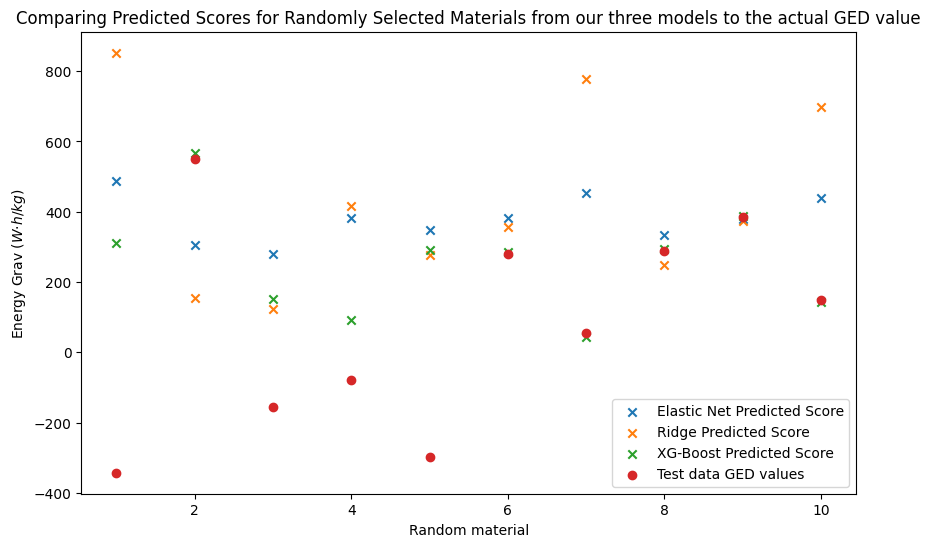

In [29]:
plt.figure(figsize=(10, 6))
plt.scatter(range(1, 11), test_pred_enet[random_index], marker='x', label='Elastic Net Predicted Score')
plt.scatter(range(1, 11), test_pred_ridge[random_index], marker='x', label='Ridge Predicted Score')
plt.scatter(range(1, 11), xg_pred[random_index], marker='x', label='XG-Boost Predicted Score')
plt.scatter(range(1, 11), random_mats, marker='o', label='Test data GED values')
plt.xlabel('Random material')
plt.ylabel(r'Energy Grav $(W⋅h/kg)$')
plt.legend()
plt.title('Comparing Predicted Scores for Randomly Selected Materials from our three models to the actual GED value')

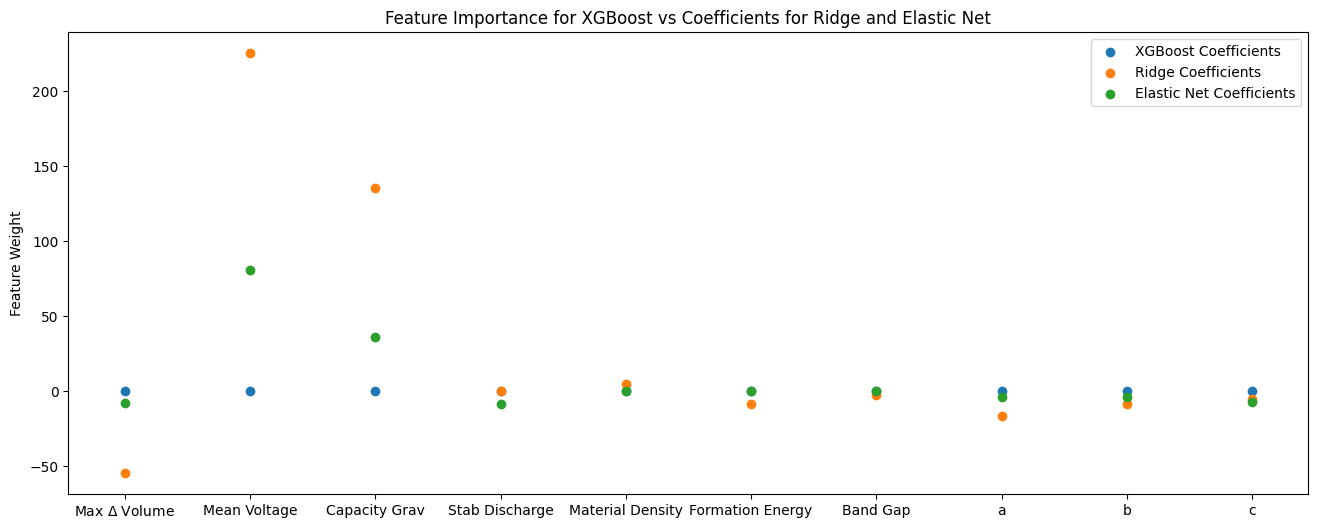

In [36]:
# Plot the feature importance for the XGBoost model against feature weights for ridge and elastic net with feature names for comparison
feature_names = [r"Max $\Delta$ Volume", r"Mean Voltage", r"Capacity Grav", r"Stab Discharge", r"Material Density", r"Formation Energy", r"Band Gap", r"a", r"b", r"c"]
plt.figure(figsize=(16, 6))
plt.scatter(feature_names, xb_f_weight, alpha=1, label='XGBoost Coefficients')
plt.scatter(feature_names, ridge_f_weight, alpha=1, label='Ridge Coefficients')
plt.scatter(feature_names, enet_f_weight, alpha=1, label='Elastic Net Coefficients')
# plt.xticks(rotation=15)
plt.ylabel('Feature Weight')
plt.title('Feature Importance for XGBoost vs Coefficients for Ridge and Elastic Net')
plt.legend()